In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

import seaborn as sns
import matplotlib.pyplot as plt

# CSV Exploration

## Patients

In [2]:
patients_df = pd.read_csv('../synthea_data/output/csv/patients.csv')
patients_df

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,MIDDLE,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME
0,c44d667b-15d5-99d4-0f69-43ca66739022,1965-08-29,NaN,999-61-1158,S99942359,X90357234X,Mrs.,Azalee124,NaN,Rippin620,NaN,Streich926,D,white,nonhispanic,F,Hudson Massachusetts US,102 Conroy Camp,Webster,Massachusetts,Worcester County,25027.00,1570,42.05,-71.83,481568.96,242241.60,40621
1,51c5e2a9-2833-5133-b85a-329b9cd53c41,1986-01-22,NaN,999-92-7443,S99972916,X87842688X,Mr.,Merrill415,Bernard308,Johnson679,JD,NaN,D,white,nonhispanic,M,Saugus Massachusetts US,175 Walker Skyway Apt 94,Cochituate,Massachusetts,Middlesex County,NaN,0,42.28,-71.35,408183.15,293397.78,53297
2,502cf42a-a540-ff39-0d59-c10d7cc1f4c7,2007-04-16,NaN,999-84-7678,S99975791,NaN,Ms.,Aletha771,Isabell86,Ondricka197,NaN,NaN,NaN,white,nonhispanic,F,Cohasset Massachusetts US,234 Powlowski Loaf Suite 94,Belmont,Massachusetts,Middlesex County,25017.00,2138,42.36,-71.20,71276.61,538108.50,526968
3,02459150-c160-03b6-f1dd-dae8fd4b3e84,1970-04-25,NaN,999-14-5874,S99948951,X56279905X,Mrs.,Cathy455,NaN,Gleason633,NaN,Wintheiser220,M,white,nonhispanic,F,Northampton Massachusetts US,833 Rippin Lock Unit 28,Douglas,Massachusetts,Worcester County,NaN,0,42.07,-71.78,296834.71,1506701.17,168634
4,3237c17d-ea0b-90f4-0743-787ef29d2404,2025-01-11,NaN,999-94-6423,NaN,NaN,NaN,Zada604,Teisha100,Metz686,NaN,NaN,NaN,white,nonhispanic,F,Swansea Massachusetts US,696 Becker Wynd,North Adams,Massachusetts,Berkshire County,25003.00,1247,42.63,-73.13,500.00,5931.33,23153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2333,213d3203-82da-c9e0-9186-840f582075bc,1925-01-21,1976-02-24,999-63-8604,S99971542,X57507989X,Mr.,Sterling124,Kraig824,Hauck852,NaN,NaN,D,black,nonhispanic,M,Lynn Massachusetts US,986 Emard Rue Suite 64,Boxford,Massachusetts,Essex County,25009.00,1921,42.73,-71.02,769574.90,0.00,113034
2334,803e8b31-ad2c-6c3a-c1be-de67544b6d2b,1925-01-21,1988-08-02,999-86-2819,S99933764,X37236096X,Mr.,Collin529,Willis868,O'Keefe54,NaN,NaN,D,black,nonhispanic,M,South Deerfield Massachusetts US,784 Schmeler Village Unit 41,Boxford,Massachusetts,Essex County,25009.00,1921,42.72,-70.99,294765.88,127376.51,113034
2335,b00222da-8016-b43b-10b0-818e19e8ed82,1925-01-21,2010-08-11,999-24-1845,S99937843,X72009102X,Mr.,Larry532,Judson999,Halvorson124,NaN,NaN,M,black,nonhispanic,M,Boston Massachusetts US,555 McGlynn Camp Unit 72,Boxford,Massachusetts,Essex County,25009.00,1921,42.72,-71.00,265298.29,168739.95,113034
2336,93adf52a-483e-ccb6-f8b3-a046e54372d6,1925-01-21,2014-05-23,999-50-6407,S99930251,X13054230X,Mr.,Wendell199,Bud153,Lowe577,NaN,NaN,M,black,nonhispanic,M,Abington Massachusetts US,788 Feil Station Unit 57,Boxford,Massachusetts,Essex County,25009.00,1921,42.72,-71.07,302942.75,141036.90,113034


### Data quality

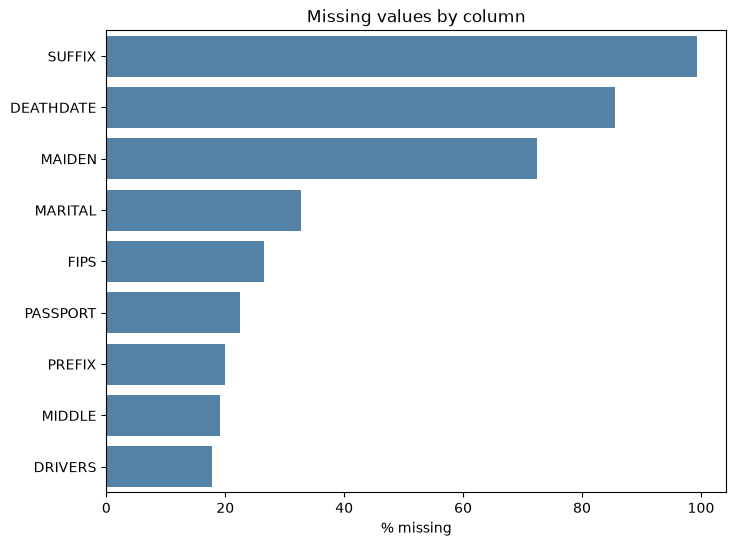

In [3]:
missing_pct = patients_df.isna().mean().sort_values(ascending=False)
missing_pct = (missing_pct[missing_pct > 0] * 100).round(1)

plt.figure(figsize=(8, 6))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="steelblue")
plt.xlabel("% missing")
plt.ylabel("")
plt.title("Missing values by column")
plt.show()

In [4]:
patients_df['BIRTHDATE'] = pd.to_datetime(patients_df['BIRTHDATE'])
patients_df['DEATHDATE'] = pd.to_datetime(patients_df['DEATHDATE'])

### Demographics

In [ ]:
# AGE is current age for living patients, age-at-death for deceased ones — the two
# populations aren't directly comparable without the IS_DECEASED split above.
today = pd.Timestamp.today()
patients_df["IS_DECEASED"] = patients_df["DEATHDATE"].notna()
patients_df["AGE"] = ((patients_df["DEATHDATE"].fillna(today) - patients_df["BIRTHDATE"]).dt.days / 365.25)

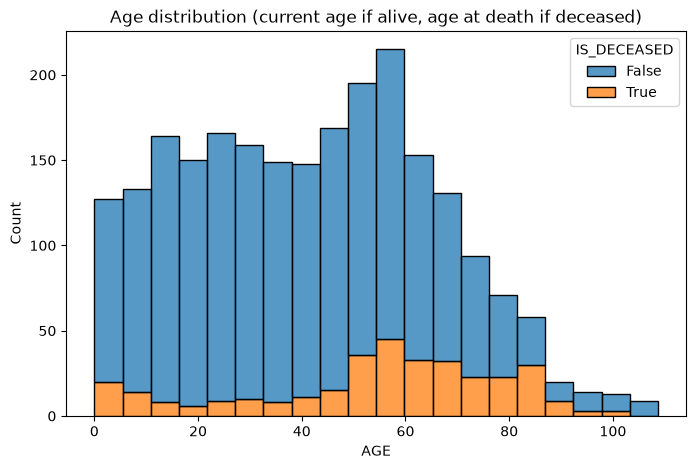

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(data=patients_df, x="AGE", hue="IS_DECEASED", multiple="stack", bins=20)
plt.title("Age distribution (current age if alive, age at death if deceased)")
plt.show()

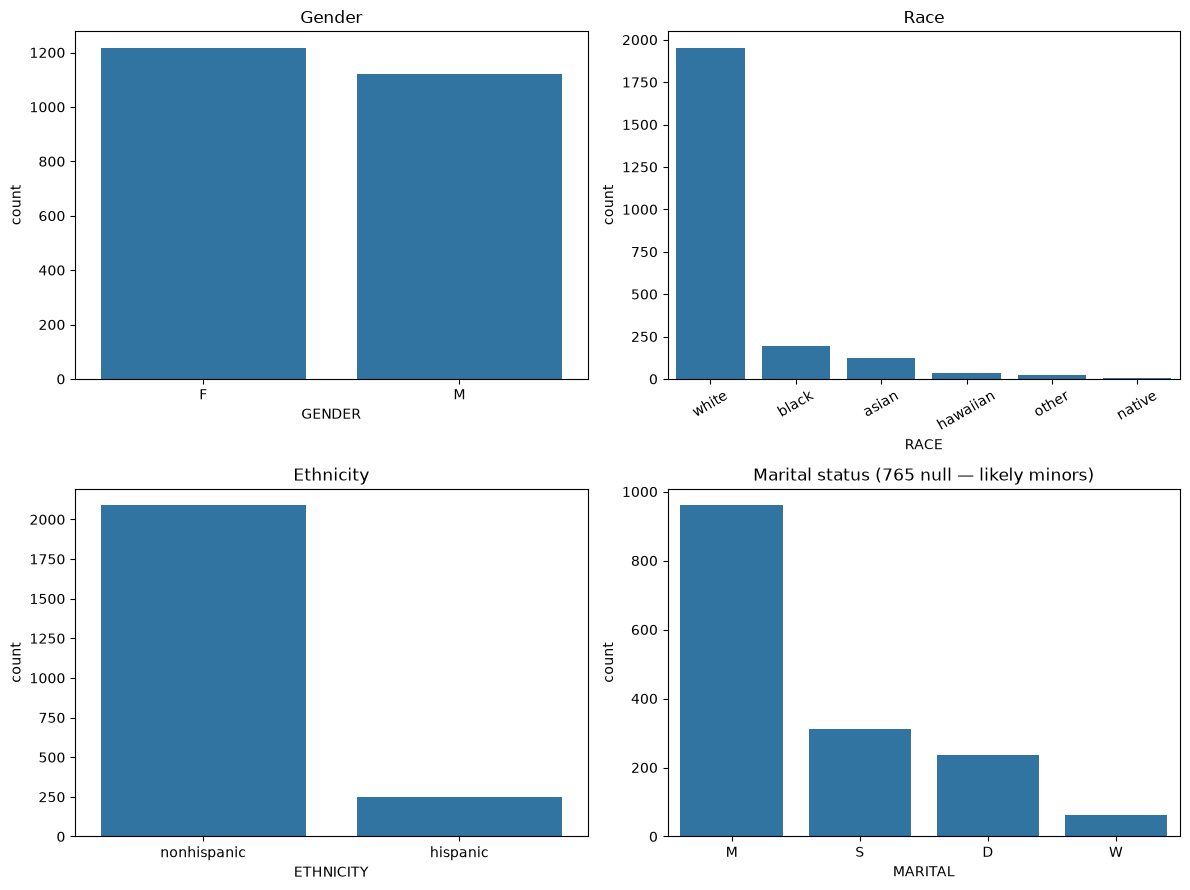

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.countplot(data=patients_df, x="GENDER", ax=axes[0, 0])
axes[0, 0].set_title("Gender")

sns.countplot(data=patients_df, x="RACE", ax=axes[0, 1], order=patients_df["RACE"].value_counts().index,)
axes[0, 1].set_title("Race")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.countplot(data=patients_df, x="ETHNICITY", ax=axes[1, 0])
axes[1, 0].set_title("Ethnicity")

sns.countplot(data=patients_df, x="MARITAL", ax=axes[1, 1], order=patients_df["MARITAL"].value_counts().index,)
axes[1, 1].set_title(f"Marital status ({patients_df['MARITAL'].isna().sum()} null — likely minors)")

plt.tight_layout()
plt.show()

In [8]:
patients_df.describe()

,BIRTHDATE,DEATHDATE,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME,AGE
count,2338,338,1716.00,2338.00,2338.00,2338.00,2338.00,2338.00,2338.00,2338.00
mean,1981-11-27 19:35:09.495295104,2007-03-24 04:02:50.414201088,25094.38,1456.79,42.26,-71.35,181684.99,349872.85,110768.84,41.92
min,1917-12-14 00:00:00,1946-05-20 00:00:00,25001.00,0.00,41.24,-73.34,100.00,0.00,13.00,0.00
25%,1963-12-19 12:00:00,1999-07-02 06:00:00,25011.00,0.00,42.12,-71.54,21624.21,20858.66,29988.25,22.12
50%,1981-11-19 00:00:00,2011-06-22 00:00:00,25017.00,1852.00,42.31,-71.14,93452.29,153750.30,70287.00,42.66
75%,2003-03-23 12:00:00,2019-10-20 18:00:00,25023.00,2150.75,42.45,-71.02,221527.34,551056.69,121828.50,59.18
max,2026-08-22 00:00:00,2026-08-20 00:00:00,44007.00,2861.00,42.88,-69.98,1640571.07,3848516.79,988857.00,108.69
std,NaN,NaN,1210.78,958.50,0.29,0.60,244955.48,470784.93,156519.27,23.82


### Socioeconomic

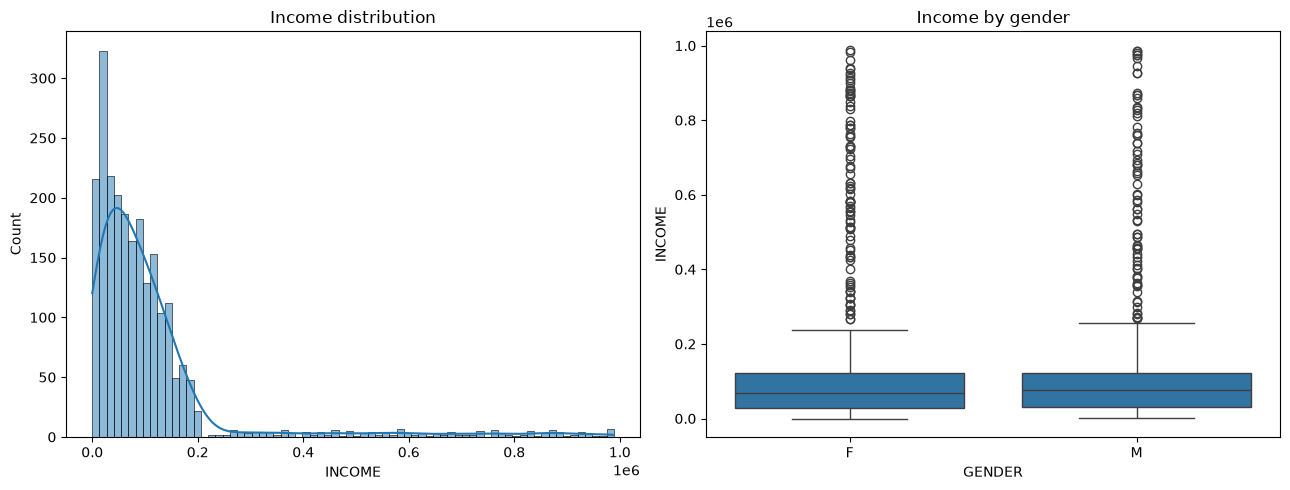

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data=patients_df, x="INCOME", kde=True, ax=axes[0])
axes[0].set_title("Income distribution")

sns.boxplot(data=patients_df, x="GENDER", y="INCOME", ax=axes[1])
axes[1].set_title("Income by gender")

plt.tight_layout()
plt.show()

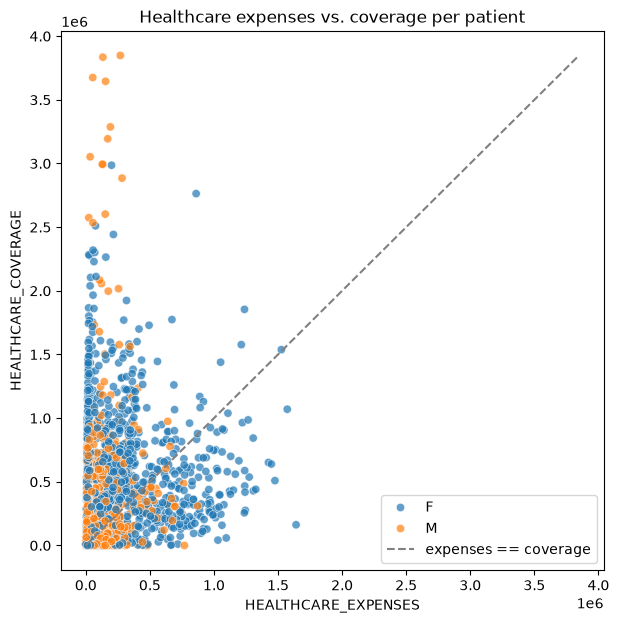

In [10]:
# negative == expenses exceed lifetime payer coverage (out-of-pocket burden);
# positive == coverage exceeds billed expenses (can happen with cumulative payer figures)
patients_df["OUT_OF_POCKET"] = patients_df["HEALTHCARE_EXPENSES"] - patients_df["HEALTHCARE_COVERAGE"]

plt.figure(figsize=(7, 7))
sns.scatterplot(
    data=patients_df, x="HEALTHCARE_EXPENSES", y="HEALTHCARE_COVERAGE",
    hue="GENDER", alpha=0.7,
)
lim = max(patients_df["HEALTHCARE_EXPENSES"].max(), patients_df["HEALTHCARE_COVERAGE"].max())
plt.plot([0, lim], [0, lim], linestyle="--", color="gray", label="expenses == coverage")
plt.legend()
plt.title("Healthcare expenses vs. coverage per patient")
plt.show()

### Geography

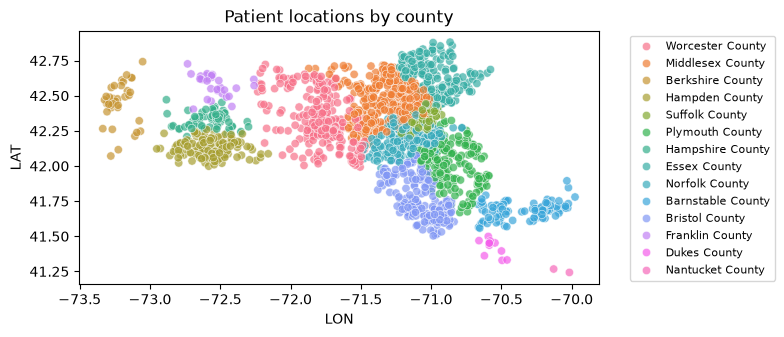

In [11]:
plt.figure(figsize=(8, 8))
sns.scatterplot(data=patients_df, x="LON", y="LAT", hue="COUNTY", alpha=0.7)
plt.gca().set_aspect("equal")  # equal degrees on both axes so the point cloud isn't visually stretched
plt.title("Patient locations by county")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### EDA summary — key insights

- **2,338 patients, 338 deceased (~14%)** — `IS_DECEASED` should gate any age/expense analysis that shouldn't mix "current age" with "age at death."
- **Income is heavily right-skewed**: mean (\$111k) is well above the median (\$70k), pulled up by a max of \$989k. Prefer median over mean when summarizing income for a patient population.
- **`HEALTHCARE_COVERAGE`'s mean (\$350k) exceeds `HEALTHCARE_EXPENSES`'s mean (\$182k)**, and coverage's max (\$3.85M) dwarfs expenses' max (\$1.64M) — coverage is not a simple fraction of expenses in this dataset. Any "out-of-pocket" derivation (`EXPENSES - COVERAGE`) can go negative; treat it as a lifetime-cumulative payer figure, not a per-claim reimbursement.
- **`FIPS` is missing for 622/2,338 patients (~27%)**, all with `ZIP == 0` — a real gap tied to specific under-specified addresses, not random. Don't join on `FIPS` without checking for these rows.
- **`MARITAL` is null for 765/2,338 patients (~33%)** — almost certainly patients too young to have a marital status recorded, not missing data. Worth confirming against `AGE` before treating it as a data quality issue.
- **Patients cluster geographically by county** (see LAT/LON plot) — consistent with Synthea generating populations from fixed regional city/town seeds rather than a uniform spatial distribution across Massachusetts.

**Regenerated at the 2,000-patient dev scale (`-p 2000` → 2,338 total) on 2026-08-22.** The `FIPS`/`MARITAL` null percentages shifted somewhat from the earlier 119-patient pilot (were ~35%/~41%, now ~27%/~33%) but the underlying causes (address specificity, minors) hold — confirms these are real structural patterns, not small-sample artifacts.

## Encounters

In [35]:
encounters_df = pd.read_csv('../synthea_data/output/csv/encounters.csv')
encounters_df

,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,c44d667b-15d5-99d4-9dc3-bb2d895495b9,1981-10-11T00:41:04Z,1981-10-11T01:06:02Z,c44d667b-15d5-99d4-0f69-43ca66739022,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,e03e23c9-4df1-3eb6-a62d-f70f02301496,wellness,410620009,Well child visit (procedure),136.80,1011.38,0.00,NaN,NaN
1,c44d667b-15d5-99d4-718f-134336f41a28,1983-10-23T00:41:04Z,1983-10-23T01:11:48Z,c44d667b-15d5-99d4-0f69-43ca66739022,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,e03e23c9-4df1-3eb6-a62d-f70f02301496,wellness,162673000,General examination of patient (procedure),136.80,1164.96,0.00,NaN,NaN
2,c44d667b-15d5-99d4-2c91-9fd0d8e38b98,1984-10-28T00:41:04Z,1984-10-28T01:16:53Z,c44d667b-15d5-99d4-0f69-43ca66739022,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,e03e23c9-4df1-3eb6-a62d-f70f02301496,wellness,162673000,General examination of patient (procedure),136.80,704.20,0.00,NaN,NaN
3,c44d667b-15d5-99d4-6280-d38ed9b4e5ac,1989-12-08T00:41:04Z,1989-12-08T00:56:04Z,c44d667b-15d5-99d4-0f69-43ca66739022,a2a41caf-758f-3962-8e5f-e6e603f93d17,de74b4c1-1b6d-3cc5-8d97-4b9d444a6748,e03e23c9-4df1-3eb6-a62d-f70f02301496,ambulatory,185345009,Encounter for symptom (procedure),85.55,92.93,0.00,75498004.00,Acute bacterial sinusitis (disorder)
4,c44d667b-15d5-99d4-db0e-663f459a4c7e,1997-07-10T00:41:04Z,1997-07-10T00:56:04Z,c44d667b-15d5-99d4-0f69-43ca66739022,a2a41caf-758f-3962-8e5f-e6e603f93d17,de74b4c1-1b6d-3cc5-8d97-4b9d444a6748,e03e23c9-4df1-3eb6-a62d-f70f02301496,ambulatory,424619006,Prenatal visit (regime/therapy),142.58,1005.38,0.00,156073000.00,Complete miscarriage (disorder)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138206,502dc964-df3b-7fa0-73ee-dbf877415a99,2025-12-14T01:10:17Z,2025-12-14T04:17:29Z,502dc964-df3b-7fa0-689e-78d3809a8df5,440fa4b8-c731-3cf5-81d9-aa3f30a37b95,5cdeccb6-c568-3206-b830-681487798473,a735bf55-83e9-331a-899d-a82a60b9f60c,ambulatory,185349003,Encounter for check up (procedure),85.55,3536.75,2829.40,103697008.00,Patient referral for dental care (procedure)
138207,502dc964-df3b-7fa0-fdd6-eba7b837e886,2025-12-21T01:10:17Z,2025-12-30T01:25:17Z,502dc964-df3b-7fa0-689e-78d3809a8df5,2e73956a-942f-36f3-b88c-f88e782e578f,941421d9-3343-3ad6-8e5b-31b1a806dd10,a735bf55-83e9-331a-899d-a82a60b9f60c,hospice,305336008,Admission to hospice (procedure),137.53,6177.13,4755.30,26929004.00,Alzheimer's disease (disorder)
138208,502dc964-df3b-7fa0-d044-a77766f658cb,2026-01-04T01:10:17Z,2026-01-04T01:25:17Z,502dc964-df3b-7fa0-689e-78d3809a8df5,440fa4b8-c731-3cf5-81d9-aa3f30a37b95,5cdeccb6-c568-3206-b830-681487798473,a735bf55-83e9-331a-899d-a82a60b9f60c,ambulatory,185345009,Encounter for symptom (procedure),85.55,85.55,68.44,444814009.00,Viral sinusitis (disorder)
138209,502dc964-df3b-7fa0-c09f-28f35610826e,2026-07-05T01:10:17Z,2026-07-05T01:47:54Z,502dc964-df3b-7fa0-689e-78d3809a8df5,7a75decf-7d3f-3b0d-8c2b-3abf0a8c7f58,9ecd2ae1-2878-3a54-93c2-ae106786378e,a735bf55-83e9-331a-899d-a82a60b9f60c,wellness,162673000,General examination of patient (procedure),136.80,919.90,735.92,NaN,NaN


In [19]:
encounters_df['ENCOUNTERCLASS'].unique()

array(['wellness', 'ambulatory', 'emergency', 'outpatient', 'inpatient',
       'urgentcare', 'virtual', 'hospice', 'snf', 'home'], dtype=object)

In [ ]:
enc_grouped = encounters_df.groupby('ENCOUNTERCLASS')['DESCRIPTION'].unique().explode().reset_index()
counts = encounters_df.groupby(['ENCOUNTERCLASS', 'DESCRIPTION']).size().rename('COUNT')
enc_grouped = enc_grouped.merge(counts, on=['ENCOUNTERCLASS', 'DESCRIPTION'])
enc_grouped

In [25]:
enc_grouped[enc_grouped['ENCOUNTERCLASS'] == 'ambulatory']

,ENCOUNTERCLASS,DESCRIPTION
0,ambulatory,Encounter for symptom (procedure)
1,ambulatory,Prenatal visit (regime/therapy)
2,ambulatory,Encounter for problem (procedure)
3,ambulatory,Encounter for check up (procedure)
4,ambulatory,Allergic disorder initial assessment (regime/t...
5,ambulatory,Outpatient procedure (procedure)
6,ambulatory,Allergic disorder follow-up assessment (regime...
7,ambulatory,Follow-up encounter (procedure)
8,ambulatory,Prenatal initial visit (regime/therapy)
9,ambulatory,Postnatal visit (regime/therapy)


In [26]:
enc_grouped[enc_grouped['ENCOUNTERCLASS'] == 'outpatient']

,ENCOUNTERCLASS,DESCRIPTION
54,outpatient,Administration of vaccine to produce active im...
55,outpatient,Consultation for treatment (procedure)
56,outpatient,Encounter for problem (procedure)
57,outpatient,Encounter for symptom (procedure)
58,outpatient,Patient encounter procedure (procedure)
59,outpatient,Encounter for check up (procedure)


## Allergies

In [12]:
allergies_df = pd.read_csv('../synthea_data/output/csv/allergies.csv')
allergies_df

,START,STOP,PATIENT,ENCOUNTER,CODE,SYSTEM,DESCRIPTION,TYPE,CATEGORY,REACTION1,DESCRIPTION1,SEVERITY1,REACTION2,DESCRIPTION2,SEVERITY2
0,1987-04-08,NaN,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-64cf-ac76a63f6471,609328004,SNOMED-CT,Allergic disposition (finding),allergy,environment,NaN,NaN,NaN,NaN,NaN,NaN
1,1987-04-08,NaN,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-64cf-ac76a63f6471,412071004,SNOMED-CT,Wheat (substance),allergy,food,271807003.00,Eruption of skin (disorder),MODERATE,NaN,NaN,NaN
2,2008-02-22,NaN,502cf42a-a540-ff39-0d59-c10d7cc1f4c7,502cf42a-a540-ff39-b415-21f8f4ec6172,609328004,SNOMED-CT,Allergic disposition (finding),allergy,environment,NaN,NaN,NaN,NaN,NaN,NaN
3,2008-02-22,NaN,502cf42a-a540-ff39-0d59-c10d7cc1f4c7,502cf42a-a540-ff39-b415-21f8f4ec6172,84489001,SNOMED-CT,Mold (organism),allergy,environment,NaN,NaN,NaN,NaN,NaN,NaN
4,2008-02-22,NaN,502cf42a-a540-ff39-0d59-c10d7cc1f4c7,502cf42a-a540-ff39-b415-21f8f4ec6172,412071004,SNOMED-CT,Wheat (substance),allergy,food,271807003.00,Eruption of skin (disorder),MODERATE,267036007.00,Dyspnea (finding),MILD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1991,1925-08-26,NaN,ac453710-a147-b8c1-d67c-c3b0beaa8c3b,ac453710-a147-b8c1-8781-7bed82dc57f2,735029006,SNOMED-CT,Shellfish (substance),allergy,food,39579001.00,Anaphylaxis (disorder),SEVERE,422587007.00,Nausea (finding),MODERATE
1992,1927-05-21,NaN,a8a5247e-740e-b3c6-677b-404216c74a38,a8a5247e-740e-b3c6-6c28-2cc8757b05d0,609328004,SNOMED-CT,Allergic disposition (finding),allergy,environment,NaN,NaN,NaN,NaN,NaN,NaN
1993,1927-05-21,NaN,a8a5247e-740e-b3c6-677b-404216c74a38,a8a5247e-740e-b3c6-6c28-2cc8757b05d0,84489001,SNOMED-CT,Mold (organism),allergy,environment,NaN,NaN,NaN,NaN,NaN,NaN
1994,1927-05-21,NaN,a8a5247e-740e-b3c6-677b-404216c74a38,a8a5247e-740e-b3c6-6c28-2cc8757b05d0,10831,RxNorm,Sulfamethoxazole / Trimethoprim,allergy,medication,271807003.00,Eruption of skin (disorder),MODERATE,247472004.00,Wheal (finding),MODERATE


In [13]:
allergies_df['PATIENT'].nunique()

388

In [14]:
allergies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1996 entries, 0 to 1995
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   START         1996 non-null   object 
 1   STOP          0 non-null      float64
 2   PATIENT       1996 non-null   object 
 3   ENCOUNTER     1996 non-null   object 
 4   CODE          1996 non-null   int64  
 5   SYSTEM        1996 non-null   object 
 6   DESCRIPTION   1996 non-null   object 
 7   TYPE          1996 non-null   object 
 8   CATEGORY      1996 non-null   object 
 9   REACTION1     859 non-null    float64
 10  DESCRIPTION1  859 non-null    object 
 11  SEVERITY1     859 non-null    object 
 12  REACTION2     523 non-null    float64
 13  DESCRIPTION2  523 non-null    object 
 14  SEVERITY2     523 non-null    object 
dtypes: float64(3), int64(1), object(11)
memory usage: 234.0+ KB


In [15]:
# drop STOP column because everything is null?
allergies_df.drop(columns=['STOP'], inplace = True)

In [16]:
allergies_df[allergies_df['PATIENT'] == '277e37e0-e456-7fda-e471-0451fc5d0c86']

,START,PATIENT,ENCOUNTER,CODE,SYSTEM,DESCRIPTION,TYPE,CATEGORY,REACTION1,DESCRIPTION1,SEVERITY1,REACTION2,DESCRIPTION2,SEVERITY2


In [17]:
allergies_df.describe()

,CODE,REACTION1,REACTION2
count,1996.00,859.00,523.00
mean,10643343672046.50,296240377.40,317943755.29
std,67818155506966.95,278981214.53,199745820.56
min,1191.00,21522001.00,21522001.00
25%,102263004.00,49727002.00,247472004.00
50%,264287008.00,267036007.00,271807003.00
75%,609328004.00,402387002.00,271807003.00
max,442571000124108.00,878820003.00,878820003.00


In [18]:
allergies_df['STOP'].unique()

KeyError: 'STOP'

## Careplans

In [19]:
careplans_df = pd.read_csv('../synthea_data/output/csv/careplans.csv')
careplans_df

,Id,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,REASONCODE,REASONDESCRIPTION
0,51c5e2a9-2833-5133-c800-ff57ffaf6f0b,1987-03-12,NaN,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-c35d-7d2e62d45dd3,384758001,Self-care interventions (procedure),NaN,NaN
1,c44d667b-15d5-99d4-202f-dd20552585d6,2013-03-14,NaN,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-8be2-fcf6faba9b86,408869004,Musculoskeletal care (regime/therapy),239872002.00,Osteoarthritis of hip (disorder)
2,51c5e2a9-2833-5133-488b-7d53bc70d6a0,2017-01-25,2017-02-10,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-41e1-3cda9a8753eb,773513001,Physiotherapy care plan (record artifact),44465007.00,Sprain of ankle (disorder)
3,c44d667b-15d5-99d4-08e5-8b4bff5cd3fd,2019-08-22,2019-09-28,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-bbac-81809254ecb7,773513001,Physiotherapy care plan (record artifact),70704007.00,Sprain of wrist (disorder)
4,502cf42a-a540-ff39-ee3a-0547ceaf8151,2008-02-07,NaN,502cf42a-a540-ff39-0d59-c10d7cc1f4c7,502cf42a-a540-ff39-4ab0-976790a5b0fb,384758001,Self-care interventions (procedure),NaN,NaN
...,...,...,...,...,...,...,...,...,...
7719,b00222da-8016-b43b-cc19-23eed40240d2,2010-02-22,2010-02-26,b00222da-8016-b43b-10b0-818e19e8ed82,b00222da-8016-b43b-a9a9-236da57487b9,736353004,Inpatient care plan (record artifact),88805009.00,Chronic congestive heart failure (disorder)
7720,b00222da-8016-b43b-2adb-3358004b7067,2010-08-08,NaN,b00222da-8016-b43b-10b0-818e19e8ed82,b00222da-8016-b43b-d53d-5de85844b5fc,736353004,Inpatient care plan (record artifact),88805009.00,Chronic congestive heart failure (disorder)
7721,93adf52a-483e-ccb6-b2cd-2b1116403bff,1971-02-10,NaN,93adf52a-483e-ccb6-f8b3-a046e54372d6,93adf52a-483e-ccb6-414a-70f954ce551c,443402002,Lifestyle education regarding hypertension (pr...,59621000.00,Essential hypertension (disorder)
7722,93adf52a-483e-ccb6-b574-350b968a3da3,2005-08-24,NaN,93adf52a-483e-ccb6-f8b3-a046e54372d6,93adf52a-483e-ccb6-1577-b1c557f0a470,386257007,Dementia management (regime/therapy),26929004.00,Alzheimer's disease (disorder)


In [20]:
careplans_df['PATIENT'].nunique()

2131

In [21]:
careplans_df.groupby(['PATIENT']).count()['Id'].sort_values(ascending=False)

PATIENT
9578dfe6-9763-3e3f-7adb-bbf3bdd6c01d    15
0f77d7b9-c61a-c5de-a408-6bf07dd34529    13
f1149501-ce2a-2224-159b-d6388c1f2761    13
6a3b2f40-9024-60d2-fb9f-08060dd1cd87    11
d3e73099-4742-7e53-66f3-043a02edad90    11
                                        ..
2c9ffa25-9c95-0f8f-0d74-fac0b88beab0     1
ffb1c6ca-1e2e-f06d-c31c-8266b675f0e9     1
fd438df7-259d-3fbd-25f8-5db65feb5126     1
fd367204-bd21-db3c-61ac-9ebbc8d587b5     1
fbce700b-8149-48a3-f78b-0237c349c3b0     1
Name: Id, Length: 2131, dtype: int64

In [22]:
careplans_df[careplans_df['PATIENT'] == '1958a572-f9fa-ade5-1a8a-cf840ca66845']

,Id,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,REASONCODE,REASONDESCRIPTION


## Claims Transactions

In [23]:
claims_txns_df = pd.read_csv('../synthea_data/output/csv/claims_transactions.csv')
claims_txns_df

,ID,CLAIMID,CHARGEID,PATIENTID,TYPE,AMOUNT,METHOD,FROMDATE,TODATE,PLACEOFSERVICE,PROCEDURECODE,MODIFIER1,MODIFIER2,DIAGNOSISREF1,DIAGNOSISREF2,DIAGNOSISREF3,DIAGNOSISREF4,UNITS,DEPARTMENTID,NOTES,UNITAMOUNT,TRANSFEROUTID,TRANSFERTYPE,PAYMENTS,ADJUSTMENTS,TRANSFERS,OUTSTANDING,APPOINTMENTID,LINENOTE,PATIENTINSURANCEID,FEESCHEDULEID,PROVIDERID,SUPERVISINGPROVIDERID
0,4eef1459-5fdf-3b46-06d2-eb40fdb88834,c44d667b-15d5-99d4-6ff6-023fd344b030,0,c44d667b-15d5-99d4-0f69-43ca66739022,CHARGE,136.80,NaN,1981-10-11T00:41:04Z,1981-10-11T01:06:02Z,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,410620009,NaN,NaN,1,NaN,NaN,NaN,1,10,Well child visit (procedure),136.80,NaN,p,0.00,0.00,NaN,0.00,c44d667b-15d5-99d4-9dc3-bb2d895495b9,NaN,NaN,1,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea
1,9dde28b3-cbbe-768c-0da5-d68207711068,c44d667b-15d5-99d4-6ff6-023fd344b030,1,c44d667b-15d5-99d4-0f69-43ca66739022,PAYMENT,NaN,CHECK,1981-10-11T00:41:04Z,1981-10-11T01:06:02Z,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,410620009,NaN,NaN,1,NaN,NaN,NaN,1,10,Well child visit (procedure),0.00,NaN,NaN,136.80,0.00,NaN,0.00,c44d667b-15d5-99d4-9dc3-bb2d895495b9,NaN,NaN,1,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea
2,36d2555b-2151-5bb1-83c7-83d64c38f98a,c44d667b-15d5-99d4-fa44-8a2b14f69cbc,3,c44d667b-15d5-99d4-0f69-43ca66739022,CHARGE,136.80,NaN,1983-10-23T00:41:04Z,1983-10-23T01:11:48Z,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,162673000,NaN,NaN,1,2.00,NaN,NaN,1,20,General examination of patient (procedure),136.80,NaN,p,0.00,0.00,NaN,0.00,c44d667b-15d5-99d4-718f-134336f41a28,NaN,NaN,1,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea
3,6da4aab6-42a3-cf62-078f-07ac98720b15,c44d667b-15d5-99d4-fa44-8a2b14f69cbc,4,c44d667b-15d5-99d4-0f69-43ca66739022,PAYMENT,NaN,CHECK,1983-10-23T00:41:04Z,1983-10-23T01:11:48Z,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,162673000,NaN,NaN,1,2.00,NaN,NaN,1,20,General examination of patient (procedure),0.00,NaN,NaN,136.80,0.00,NaN,0.00,c44d667b-15d5-99d4-718f-134336f41a28,NaN,NaN,1,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea
4,d577fc7f-0fcc-1bbf-f2b0-d71bf387455e,c44d667b-15d5-99d4-52db-83310a7563ea,6,c44d667b-15d5-99d4-0f69-43ca66739022,CHARGE,136.80,NaN,1984-10-28T00:41:04Z,1984-10-28T01:16:53Z,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,162673000,NaN,NaN,1,NaN,NaN,NaN,1,20,General examination of patient (procedure),136.80,NaN,p,0.00,0.00,NaN,0.00,c44d667b-15d5-99d4-2c91-9fd0d8e38b98,NaN,NaN,1,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2247674,a9ecf437-6209-0429-34fd-79b25f2c87d3,502dc964-df3b-7fa0-0dab-9f19c4138632,2922389,502dc964-df3b-7fa0-689e-78d3809a8df5,CHARGE,431.40,NaN,2026-07-19T03:49:38Z,2026-07-19T04:00:23Z,440fa4b8-c731-3cf5-81d9-aa3f30a37b95,243085009,NaN,NaN,1,NaN,NaN,NaN,1,1,Oral health education (procedure),431.40,NaN,1,0.00,0.00,NaN,0.00,502dc964-df3b-7fa0-0bec-a4f003e0f5e1,NaN,502dc964-df3b-7fa0-d5f0-8e1fcce2f496,1,5cdeccb6-c568-3206-b830-681487798473,5cdeccb6-c568-3206-b830-681487798473
2247675,66b88241-0a6a-7b3d-c577-cb21f4cd3f5e,502dc964-df3b-7fa0-0dab-9f19c4138632,2922390,502dc964-df3b-7fa0-689e-78d3809a8df5,PAYMENT,NaN,ECHECK,2026-07-19T03:49:38Z,2026-07-19T04:00:23Z,440fa4b8-c731-3cf5-81d9-aa3f30a37b95,243085009,NaN,NaN,1,NaN,NaN,NaN,1,1,Oral health education (procedure),0.00,NaN,NaN,345.12,0.00,NaN,86.28,502dc964-df3b-7fa0-0bec-a4f003e0f5e1,NaN,502dc964-df3b-7fa0-d5f0-8e1fcce2f496,1,5cdeccb6-c568-3206-b830-681487798473,5cdeccb6-c568-3206-b830-681487798473
2247676,d1710482-14d4-f67a-96ef-9643e99a7ebd,502dc964-df3b-7fa0-0dab-9f19c4138632,2922391,502dc964-df3b-7fa0-689e-78d3809a8df5,TRANSFEROUT,NaN,NaN,2026-07-19T03:49:38Z,2026-07-19T04:00:23Z,440fa4b8-c731-3cf5-81d9-aa3f30a37b95,243085009,NaN,NaN,1,NaN,NaN,NaN,1,1,Oral health education (procedure),0.00,NaN,NaN,0.00,0.00,86.28,86.28,